In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from keras.layers import LSTM, Dense, Dropout, SimpleRNN, GRU
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

Understanding dataset nature

In [31]:
data = pd.read_csv('AEP_hourly.csv')
data.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [32]:
data.tail()

,Datetime,AEP_MW
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


In [33]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  str    
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), str(1)
memory usage: 1.9 MB


Preparing data for time series forecasting

In [34]:
data['Datetime'] = pd.to_datetime(data['Datetime'])

In [35]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  121273 non-null  datetime64[us]
 1   AEP_MW    121273 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 1.9 MB


In [36]:
data.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [37]:
data.tail()

,Datetime,AEP_MW
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


In [38]:
data.set_index('Datetime', inplace = True)

In [39]:
data.head()

,AEP_MW
Datetime,
2004-12-31 01:00:00,13478.0
2004-12-31 02:00:00,12865.0
2004-12-31 03:00:00,12577.0
2004-12-31 04:00:00,12517.0
2004-12-31 05:00:00,12670.0


EDA

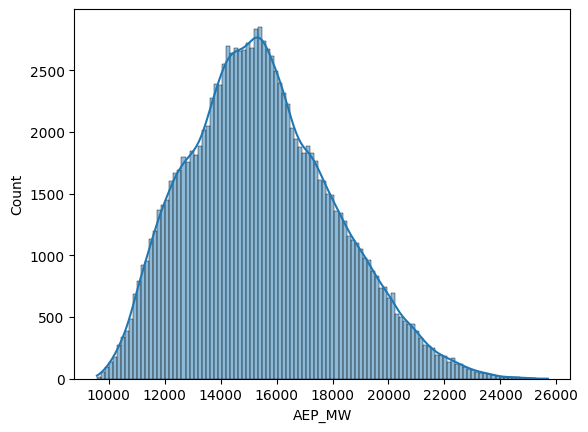

In [40]:
plt.figure()
sns.histplot(data['AEP_MW'], kde = True)
plt.show()

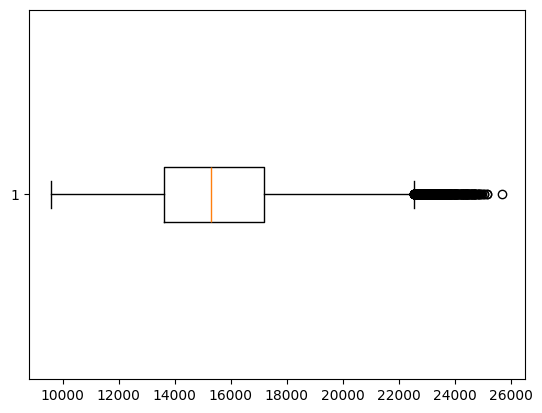

In [41]:
plt.boxplot(data, vert = False)
plt.show()

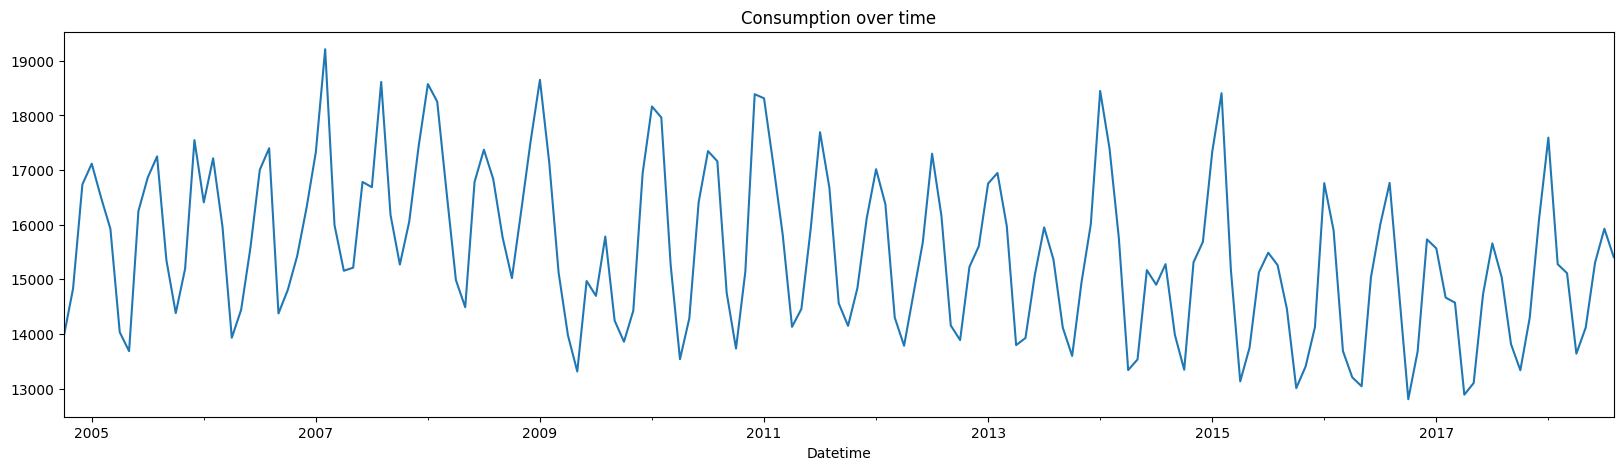

In [42]:
data_2 = data[['AEP_MW']].resample('ME').mean().copy()
data_2['AEP_MW'].plot(title=f"Consumption over time", figsize=(20, 5))
plt.show()

Train test Split

In [43]:
size = int(len(data_2)*0.8)
train_dataset = data_2.iloc[:size].copy()
test_dataset = data_2.iloc[size:].copy()

In [44]:
print(f"p_value: {sts.adfuller(train_dataset['AEP_MW'])[1]}")

p_value: 0.6416605289899769


In [45]:
train_dataset[['AEP_MW']]

,AEP_MW
Datetime,
2004-10-31,13947.537736
2004-11-30,14830.440278
2004-12-31,16737.720430
2005-01-31,17117.088710
2005-02-28,16496.644345
...,...
2015-06-30,15126.598611
2015-07-31,15487.528226
2015-08-31,15260.602151


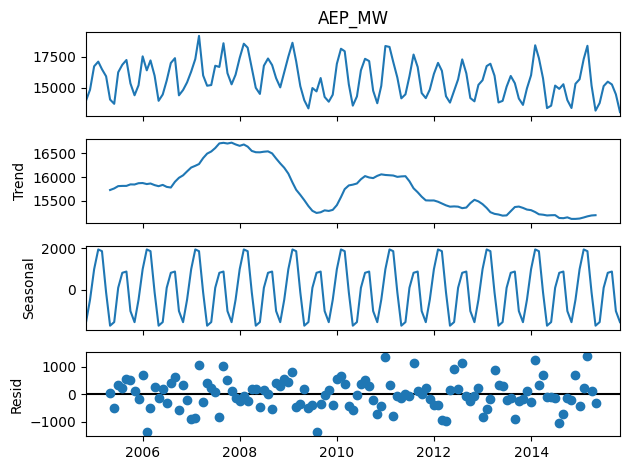

In [46]:
s_dec_additive = seasonal_decompose(train_dataset['AEP_MW'], model='additive')
s_dec_additive.plot()
plt.show()

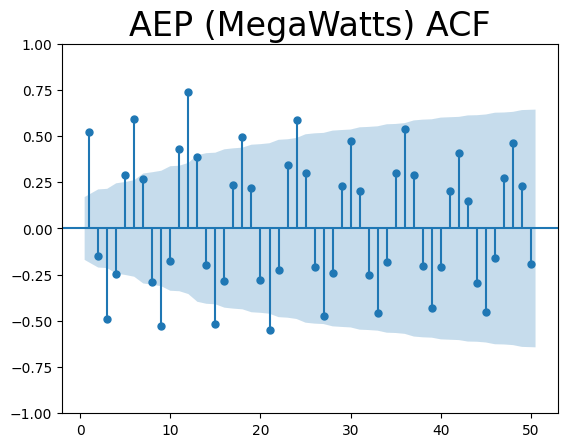

In [47]:
sgt.plot_acf(train_dataset['AEP_MW'], lags=50, zero=False)
plt.title("AEP (MegaWatts) ACF", size=24)    
plt.show()

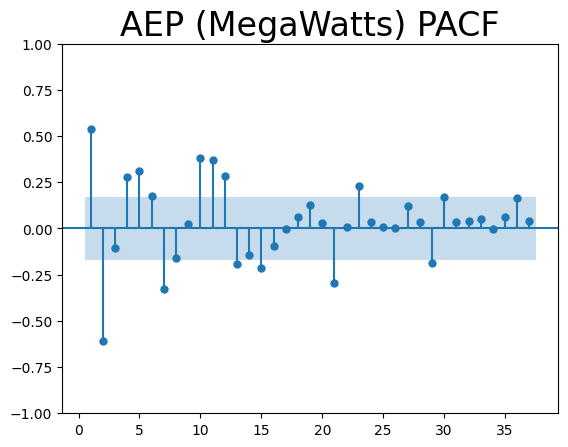

In [48]:
sgt.plot_pacf(train_dataset['AEP_MW'], lags=37, zero=False, method='ols')
plt.title("AEP (MegaWatts) PACF", size=24)
plt.show()

In [49]:
stationary_data = train_dataset[['AEP_MW']].diff(periods = 12).dropna().copy()

In [50]:
stationary_data

,AEP_MW
Datetime,
2005-10-31,433.844498
2005-11-30,364.441667
2005-12-31,810.868280
2006-01-31,-707.252688
2006-02-28,719.383929
...,...
2015-06-30,-41.783333
2015-07-31,585.903226
2015-08-31,-17.698925


In [51]:
print(f"p_value: {sts.adfuller(stationary_data['AEP_MW'])[1]}")

p_value: 0.004762544539967442


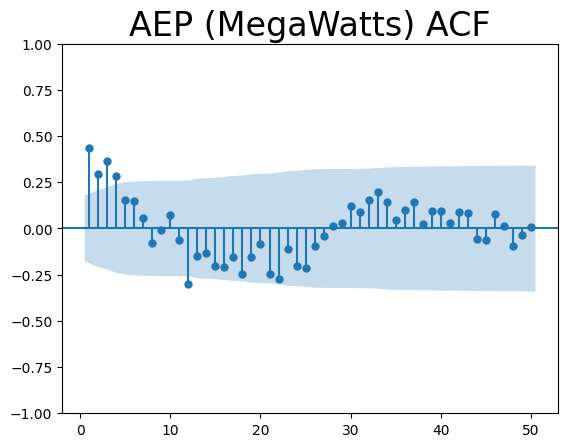

In [52]:
sgt.plot_acf(stationary_data['AEP_MW'], lags=50, zero=False)
plt.title("AEP (MegaWatts) ACF", size=24)    
plt.show()

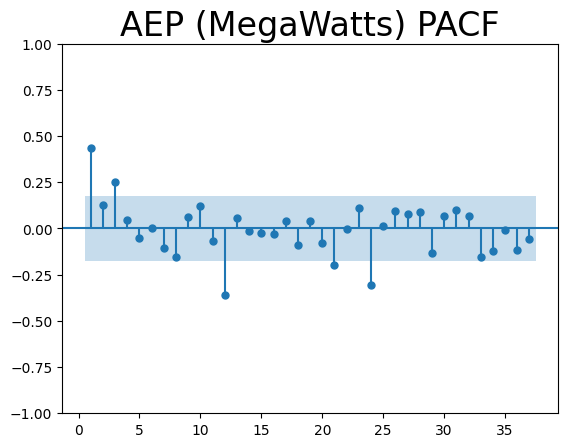

In [53]:
sgt.plot_pacf(stationary_data['AEP_MW'], lags=37, zero=False, method='ols')
plt.title("AEP (MegaWatts) PACF", size=24)
plt.show()

In [54]:
model_sarima = SARIMAX(train_dataset['AEP_MW'],
                       order=(3, 1, 4),           
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

results_sarima = model_sarima.fit()
print(results_sarima.summary())

                                      SARIMAX Results                                       
Dep. Variable:                               AEP_MW   No. Observations:                  133
Model:             SARIMAX(3, 1, 4)x(1, 1, [1], 12)   Log Likelihood                -815.406
Date:                              Mon, 08 Jun 2026   AIC                           1650.813
Time:                                      08:46:07   BIC                           1677.160
Sample:                                  10-31-2004   HQIC                          1661.484
                                       - 10-31-2015                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2390      0.319      0.750      0.453      -0.386       0.864
ar.L2         -0.74

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [55]:
n_steps = len(test_dataset)
forecast_obj = results_sarima.get_forecast(steps=n_steps)

y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

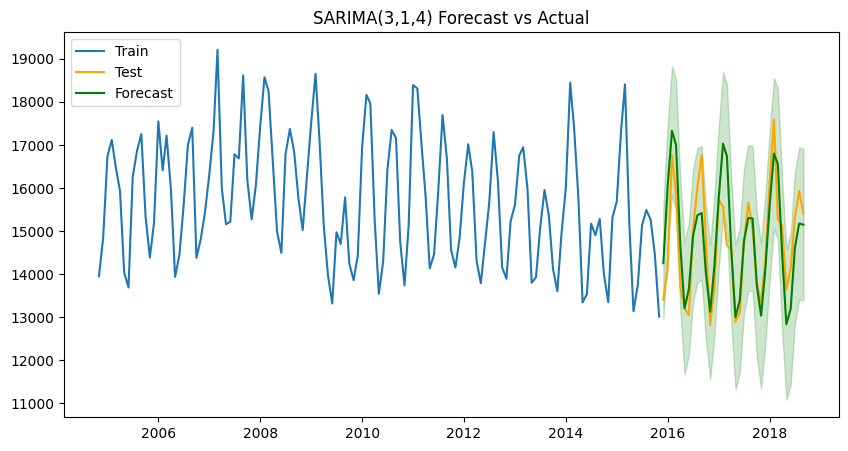

In [56]:
plt.figure(figsize=(10,5))
plt.plot(train_dataset.index, train_dataset['AEP_MW'], label='Train')
plt.plot(test_dataset.index, test_dataset['AEP_MW'], label='Test', color='orange')
plt.plot(y_pred.index, y_pred, label='Forecast', color='green')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.legend()
plt.title('SARIMA(3,1,4) Forecast vs Actual')
plt.show()

In [57]:
mae = mean_absolute_error(test_dataset['AEP_MW'], y_pred)
rmse = np.sqrt(mean_squared_error(test_dataset['AEP_MW'], y_pred))

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE : 636.34
RMSE: 820.82


In [58]:
model = pm.auto_arima(train_dataset, 
                      start_p=1, start_q=1,
                      max_p=5, max_q=5,
                      m=12,              
                      start_P=1, seasonal=True,
                      start_Q = 1,
                      d=1, D=1,          
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=1942.477, Time=0.81 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1988.983, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1959.970, Time=0.15 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1944.275, Time=0.18 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1944.697, Time=0.24 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=1953.174, Time=0.24 sec
 ARIMA(1,1,1)(2,1,1)[12]             : AIC=1944.474, Time=0.63 sec
 ARIMA(1,1,1)(1,1,2)[12]             : AIC=inf, Time=1.31 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1969.110, Time=0.04 sec
 ARIMA(1,1,1)(0,1,2)[12]             : AIC=1942.992, Time=0.55 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1951.195, Time=0.47 sec
 ARIMA(1,1,1)(2,1,2)[12]             : AIC=inf, Time=1.57 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1941.499, Time=0.48 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1952.338, Time=0.14 sec
 ARIMA(0,1,1)(2,1,1)[12]     

In [59]:
model_sarima = SARIMAX(train_dataset['AEP_MW'],
                       order=(0, 1, 1),           
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

results_sarima = model_sarima.fit()
print(results_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                             AEP_MW   No. Observations:                  133
Model:             SARIMAX(0, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -848.456
Date:                            Mon, 08 Jun 2026   AIC                           1704.911
Time:                                    08:46:20   BIC                           1715.565
Sample:                                10-31-2004   HQIC                          1709.229
                                     - 10-31-2015                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5930      0.093     -6.390      0.000      -0.775      -0.411
ar.S.L12       0.1444      0.122   

In [60]:
n_steps = len(test_dataset)
forecast_obj = results_sarima.get_forecast(steps=n_steps)

y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

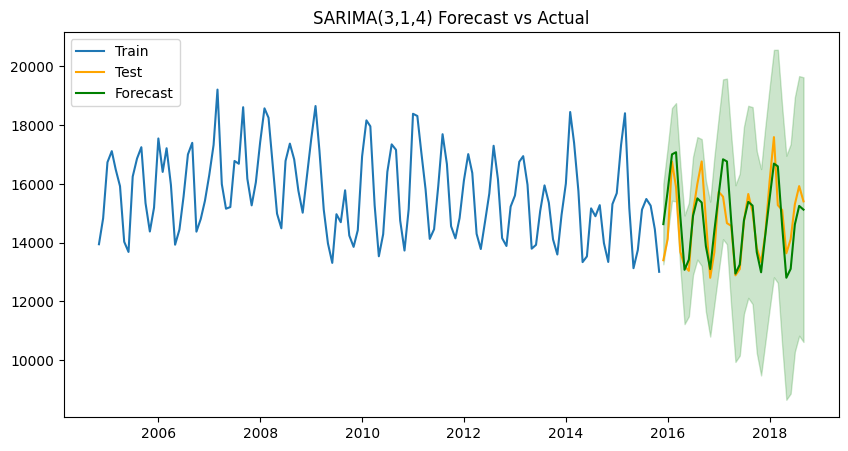

In [61]:
plt.figure(figsize=(10,5))
plt.plot(train_dataset.index, train_dataset['AEP_MW'], label='Train')
plt.plot(test_dataset.index, test_dataset['AEP_MW'], label='Test', color='orange')
plt.plot(y_pred.index, y_pred, label='Forecast', color='green')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.legend()
plt.title('SARIMA(3,1,4) Forecast vs Actual')
plt.show()

In [62]:
mae = mean_absolute_error(test_dataset['AEP_MW'], y_pred)
rmse = np.sqrt(mean_squared_error(test_dataset['AEP_MW'], y_pred))

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE : 636.41
RMSE: 824.97


In [63]:
model_arima = ARIMA(train_dataset['AEP_MW'], order=(3,1,4))
results_arima = model_arima.fit()
results_arima.summary()

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 AEP_MW   No. Observations:                  133
Model:                 ARIMA(3, 1, 4)   Log Likelihood               -1087.398
Date:                Mon, 08 Jun 2026   AIC                           2190.797
Time:                        08:46:21   BIC                           2213.859
Sample:                    10-31-2004   HQIC                          2200.168
                         - 10-31-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0214      0.029      0.729      0.466      -0.036       0.079
ar.L2         -0.0113      0.029     -0.390      0.697      -0.068       0.045
ar.L3         -0.9832      0.028    -35.301      0.000      -1.038      -0.929
ma.L1         -0.2451      0.105     -2.337      0.019      -0.451      -0.040
ma.L2          0.0358      0.120      0.298      0.766      -0.200       0.272
ma.L3          0.9461      0.138      6.857      0.000       0.676       1.216
ma.L4         -0.1772      0.067     -2.630      0.009      -0.309      -0.045
sigma2      7.528e+05   2.85e-07   2.65e+12      0.000    7.53e+05    7.53e+05
===================================================================================
Ljung-Box (L1) (Q):                   1.89   Jarque-Bera (JB):                 0.56
Prob(Q):                              0.17   Prob(JB):                         0.75
Heteroskedasticity (H):               0.45   Skew:                             0.10
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.15e+28. Standard errors may be unstable.
"""

In [64]:
n_steps = len(test_dataset)
forecast_obj = results_arima.get_forecast(steps=n_steps)

y_pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

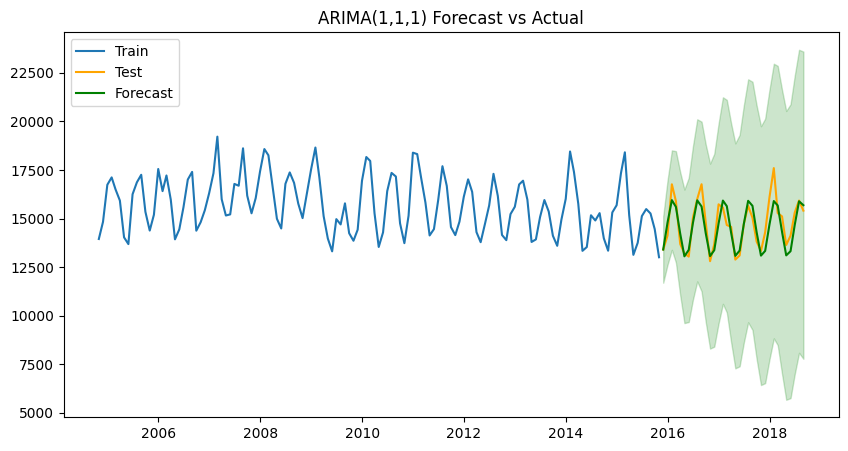

In [65]:
plt.figure(figsize=(10,5))
plt.plot(train_dataset.index, train_dataset['AEP_MW'], label='Train')
plt.plot(test_dataset.index, test_dataset['AEP_MW'], label='Test', color='orange')
plt.plot(y_pred.index, y_pred, label='Forecast', color='green')
plt.fill_between(conf_int.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='green', alpha=0.2)
plt.legend()
plt.title('ARIMA(1,1,1) Forecast vs Actual')
plt.show()

In [66]:
mae = mean_absolute_error(test_dataset['AEP_MW'], y_pred)
rmse = np.sqrt(mean_squared_error(test_dataset['AEP_MW'], y_pred))

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE : 517.45
RMSE: 650.41


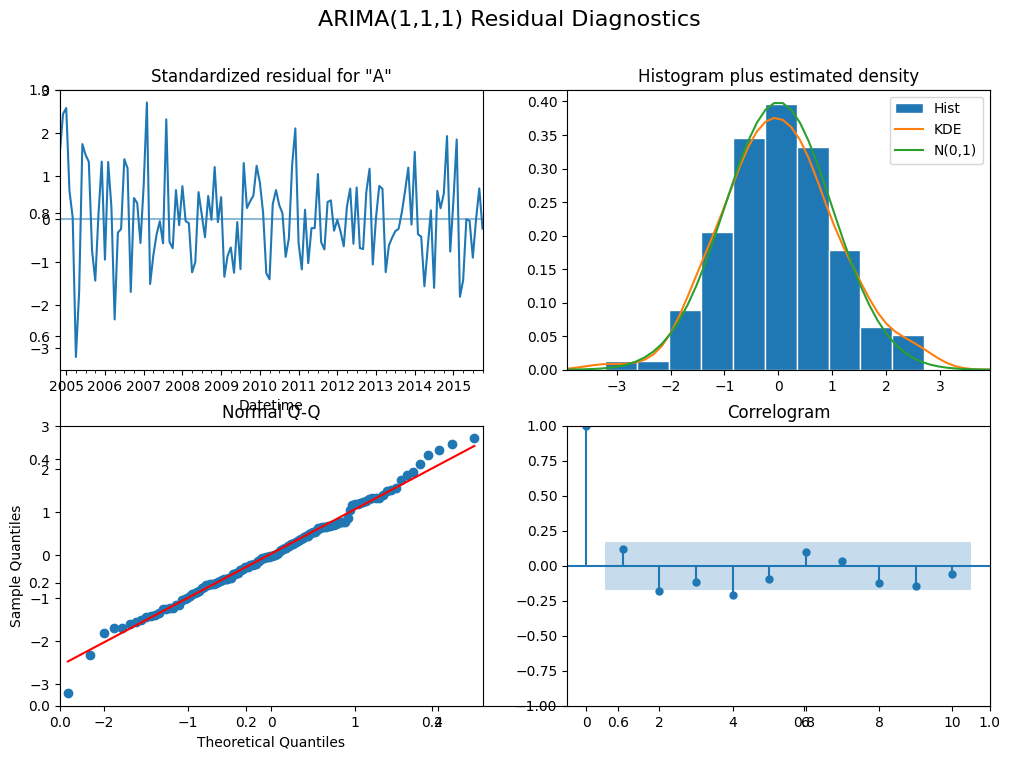

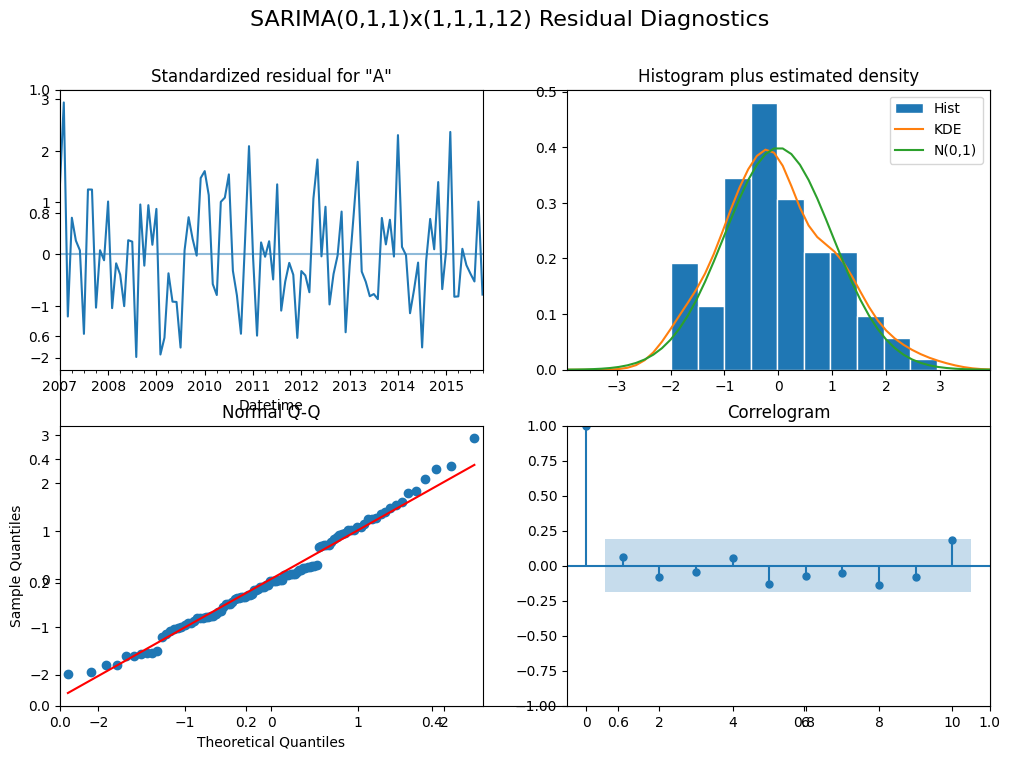

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
results_arima.plot_diagnostics(fig=fig)
plt.suptitle("ARIMA(3,1,4) Residual Diagnostics", fontsize=16)
plt.show()

fig, ax = plt.subplots(figsize=(12, 8))
results_sarima.plot_diagnostics(fig=fig)
plt.suptitle("SARIMA(0,1,1)x(1,1,1,12) Residual Diagnostics", fontsize=16)
plt.show()

In [68]:
train_proph = train_dataset.copy()
train_proph.reset_index(inplace = True)
train_proph.head()

,Datetime,AEP_MW
0,2004-10-31,13947.537736
1,2004-11-30,14830.440278
2,2004-12-31,16737.720430
3,2005-01-31,17117.088710
4,2005-02-28,16496.644345


In [69]:
train_proph = train_proph.rename(columns={'Datetime': 'ds', 'AEP_MW': 'y'})
train_proph.head()

,ds,y
0,2004-10-31,13947.537736
1,2004-11-30,14830.440278
2,2004-12-31,16737.720430
3,2005-01-31,17117.088710
4,2005-02-28,16496.644345


In [70]:
model = Prophet()
model.fit(train_proph)

08:46:22 - cmdstanpy - INFO - Chain [1] start processing
08:46:22 - cmdstanpy - INFO - Chain [1] done processing


In [71]:
test_proph = test_dataset.copy()
test_proph.reset_index(inplace = True)
test_proph.head()

,Datetime,AEP_MW
0,2015-11-30,13403.000000
1,2015-12-31,14123.189516
2,2016-01-31,16760.747312
3,2016-02-29,15895.386494
4,2016-03-31,13687.551817


In [72]:
test_proph = test_proph.rename(columns={'Datetime': 'ds', 'AEP_MW': 'y'})
test_proph.head()

,ds,y
0,2015-11-30,13403.000000
1,2015-12-31,14123.189516
2,2016-01-31,16760.747312
3,2016-02-29,15895.386494
4,2016-03-31,13687.551817


In [73]:
forecast = model.predict(test_proph)

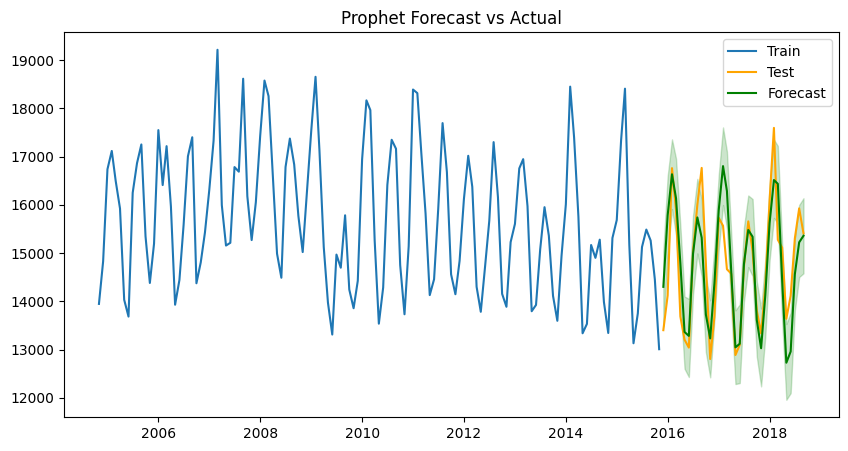

In [74]:
plt.figure(figsize=(10,5))
plt.plot(train_proph['ds'], train_proph['y'], label='Train')
plt.plot(test_proph['ds'], test_proph['y'], label='Test', color='orange')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='green')
plt.fill_between(forecast['ds'],
                 forecast['yhat_upper'],
                 forecast['yhat_lower'],
                 color='green', alpha=0.2)
plt.legend()
plt.title('Prophet Forecast vs Actual')
plt.show()

In [75]:
mae = mean_absolute_error(test_proph['y'], forecast['yhat'])
rmse = np.sqrt(mean_squared_error(test_proph['y'], forecast['yhat']))

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE : 581.13
RMSE: 762.77


In [76]:
data_3 = data_2.copy()
data_3.head()

,AEP_MW
Datetime,
2004-10-31,13947.537736
2004-11-30,14830.440278
2004-12-31,16737.720430
2005-01-31,17117.088710
2005-02-28,16496.644345


In [77]:
#scaler = MinMaxScaler(feature_range=(0, 1))
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_3)

In [78]:
window_size = 12
X = []
y = []
target_dates = data_3.index[window_size:]

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i - window_size:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, target_dates, test_size=0.2, shuffle=False
)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [79]:
model = Sequential()
model.add(SimpleRNN(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(SimpleRNN(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
custom_learning_rate = 0.001
optimizer = Adam(learning_rate=custom_learning_rate)

model.compile(optimizer=optimizer, loss='mean_squared_error')

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [80]:
history = model.fit(X_train, 
                    y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_split=0.1,
                    callbacks=[early_stop])

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test_1 = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

rmse = np.sqrt(np.mean((y_test_1 - predictions)**2))
mae = np.mean(abs(y_test_1 - predictions))
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 0.8521 - val_loss: 0.5968
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.8060 - val_loss: 0.4762
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.5766 - val_loss: 0.4239
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.5303 - val_loss: 0.3729
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4158 - val_loss: 0.3134
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4303 - val_loss: 0.1860
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4047 - val_loss: 0.2247
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3502 - val_loss: 0.2400
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3897 - val_loss: 0.2288
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3656 - val_loss: 0.1917
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2812 - val_loss: 0.1826
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3066 - val_l

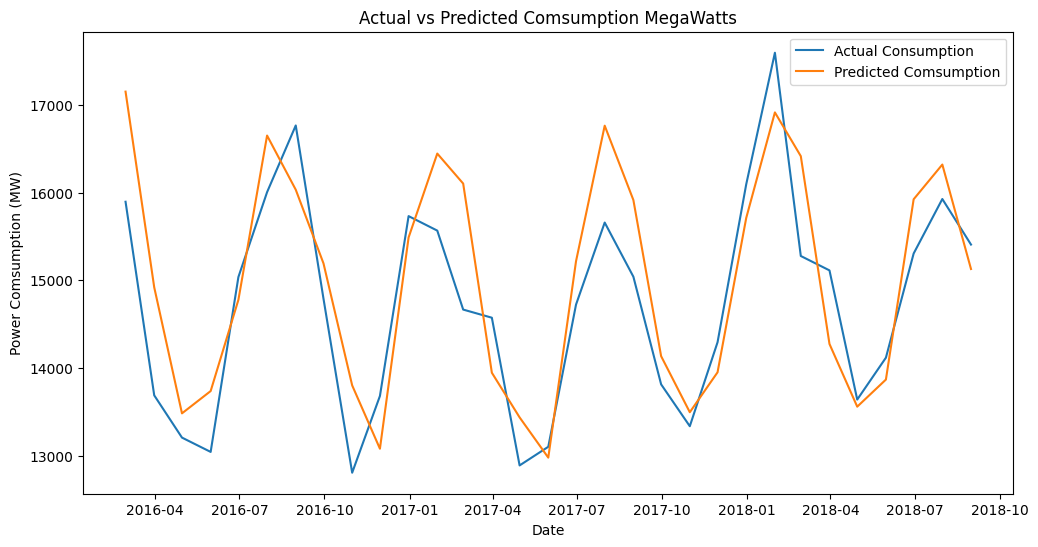

In [81]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_1, label='Actual Consumption')
plt.plot(dates_test, predictions, label='Predicted Comsumption')
plt.title('Actual vs Predicted Comsumption MegaWatts')
plt.xlabel('Date')
plt.ylabel('Power Comsumption (MW)')
plt.legend()
plt.show()

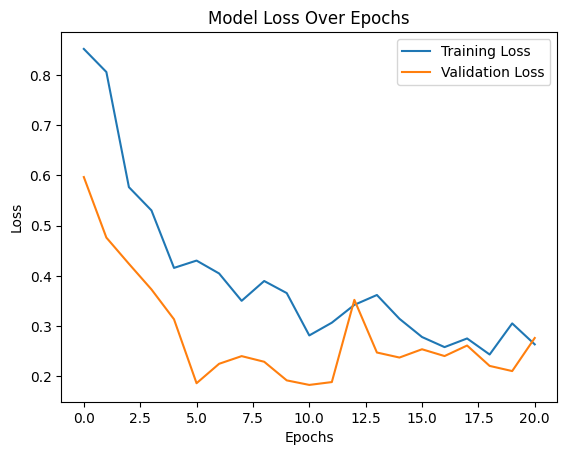

In [82]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [83]:
model = Sequential()
model.add(LSTM(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
custom_learning_rate = 0.001
optimizer = Adam(learning_rate=custom_learning_rate)

model.compile(optimizer=optimizer, loss='mean_squared_error')

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [84]:
history = model.fit(X_train, 
                    y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_split=0.1,
                    callbacks=[early_stop])

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test_1 = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

rmse = np.sqrt(np.mean((y_test_1 - predictions)**2))
mae = np.mean(abs(y_test_1 - predictions))
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.9801 - val_loss: 1.3079
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.9163 - val_loss: 1.2547
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9128 - val_loss: 1.1973
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.8535 - val_loss: 1.1348
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.8204 - val_loss: 1.0673
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7726 - val_loss: 1.0143
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7282 - val_loss: 1.0956
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7192 - val_loss: 1.2804
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7311 - val_loss: 0.9674
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.7092 - val_loss: 0.9279
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.6511 - val_loss: 0.9492
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.6286 - val_lo

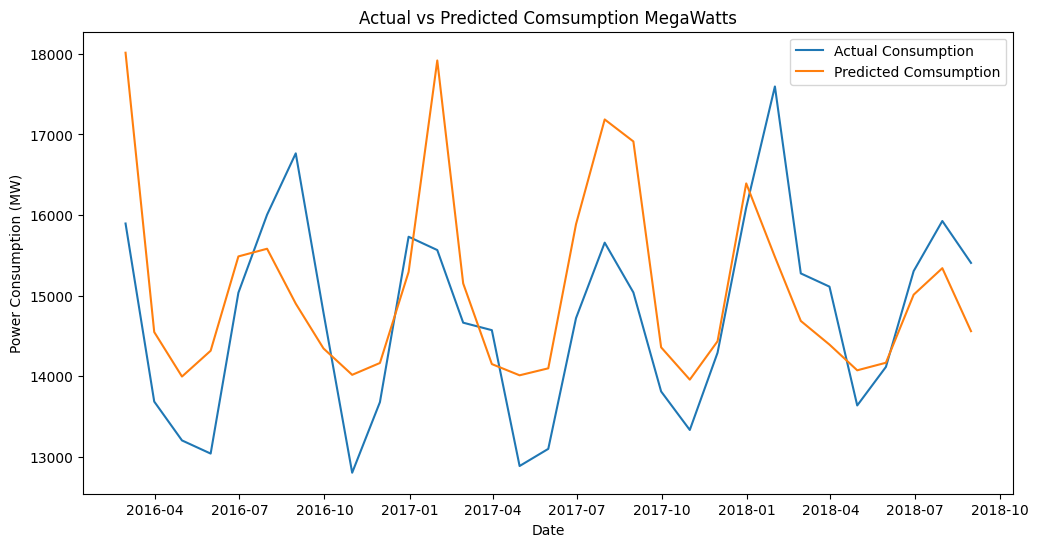

In [85]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_1, label='Actual Consumption')
plt.plot(dates_test, predictions, label='Predicted Comsumption')
plt.title('Actual vs Predicted Comsumption MegaWatts')
plt.xlabel('Date')
plt.ylabel('Power Consumption (MW)')
plt.legend()
plt.show()

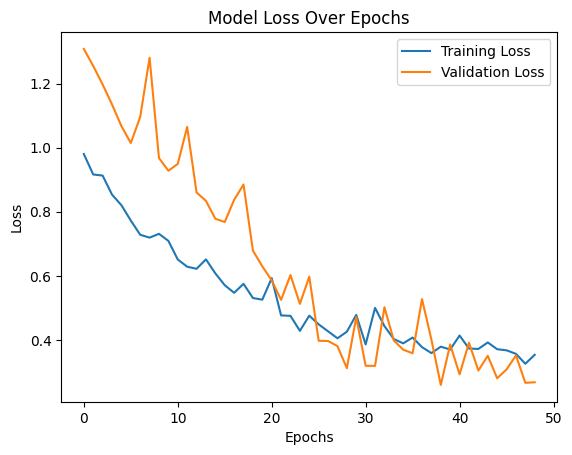

In [86]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [87]:
model = Sequential()
model.add(GRU(units=128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(GRU(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
custom_learning_rate = 0.001
optimizer = Adam(learning_rate=custom_learning_rate)

model.compile(optimizer=optimizer, loss='mean_squared_error')

c:\Users\victo\OneDrive\Documents\Data science course\Machine-Learning-2-Capstone\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [88]:
history = model.fit(X_train, 
                    y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_split=0.1,
                    callbacks=[early_stop])

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test_1 = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

rmse = np.sqrt(np.mean((y_test_1 - predictions)**2))
mae = np.mean(abs(y_test_1 - predictions))
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - loss: 1.0263 - val_loss: 1.3242
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.9721 - val_loss: 1.3200
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.9280 - val_loss: 1.3007
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8799 - val_loss: 1.2583
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.8214 - val_loss: 1.1877
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.7387 - val_loss: 1.1324
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.6491 - val_loss: 1.0084
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.5624 - val_loss: 0.8575
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.4923 - val_loss: 0.7349
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.4448 - val_loss: 0.6517
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.3964 - val_loss: 0.6057
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.3674 - val_l

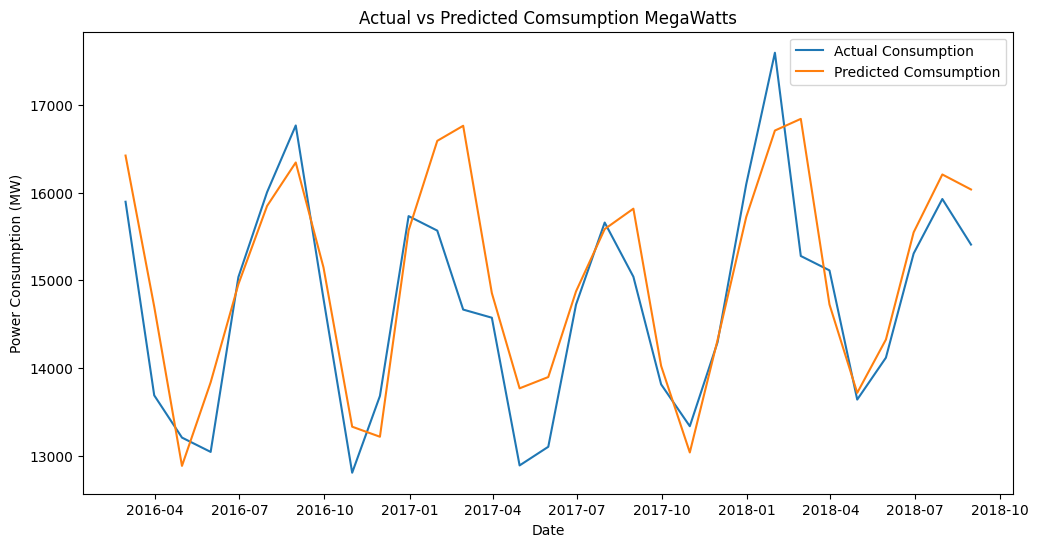

In [89]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_1, label='Actual Consumption')
plt.plot(dates_test, predictions, label='Predicted Comsumption')
plt.title('Actual vs Predicted Comsumption MegaWatts')
plt.xlabel('Date')
plt.ylabel('Power Consumption (MW)')
plt.legend()
plt.show()

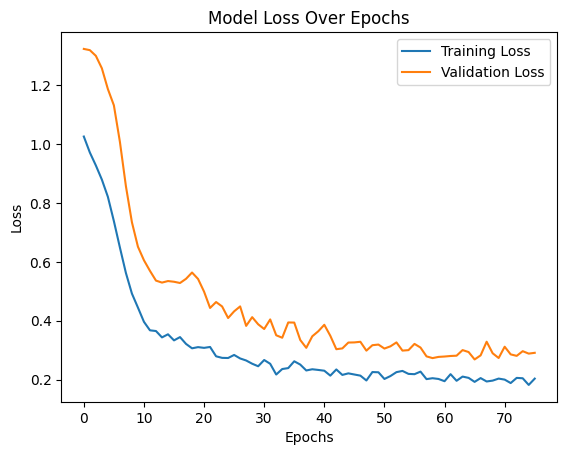

In [90]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()